<a href="https://colab.research.google.com/github/maxwellugwu808-ui/FFNetwork/blob/main/class_based_mnist_image_classification_with_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Extract features and labels
X, y = mnist.data, mnist.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (70000, 784)
Shape of y: (70000,)


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

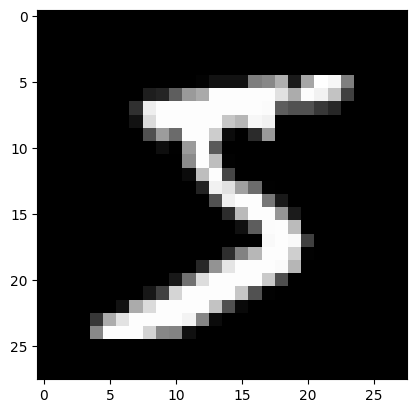

In [4]:
plt.imshow(X[0].reshape(28, 28), cmap='gray')

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape

(56000, 784)

In [6]:
xtrain = torch.tensor(X_train, dtype=torch.float32)
ytrain = torch.tensor(y_train.astype(int), dtype=torch.long)
xtest = torch.tensor(X_test, dtype=torch.float32)
ytest = torch.tensor(y_test.astype(int), dtype=torch.long)
ytest

tensor([2, 6, 6,  ..., 6, 6, 8])

In [7]:
class ImageClassify(nn.Module):
  def __init__(self):
    super().__init__()
    self.first =  nn.Linear(784, 28)

    self.second = nn.Linear(28, 16)

    self.third = nn.Linear(16,10)
  def forward(self, x):
    x = F.relu(self.first(x))
    x = F.relu(self.second(x))
    x = self.third(x)
    return x

In [8]:

model = ImageClassify()
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
numepoch = 20
lossvalues = torch.zeros(numepoch)

training_acc = []

for epochi in range(numepoch):
    yhat = model.forward(xtrain)
    losses = loss(yhat, ytrain)
    lossvalues[epochi] = losses



    optimizer.zero_grad()
    losses.backward()
    optimizer.step()


    # compute accuracy
    matches = torch.argmax(yhat,axis=1) == ytrain # booleans (false/true)
    matchesNumeric = matches.float()              # convert to numbers (0/1)
    accuracyPct = 100*torch.mean(matchesNumeric)  # average and x100
    training_acc.append( accuracyPct )            # add to list of accuracies

    # final forward pass
predictions = model.forward(xtrain)

predlabels = torch.argmax(predictions,axis=1)
totalacc = 100*torch.mean((predlabels == ytrain).float())


In [10]:
totalacc

tensor(42.5161)

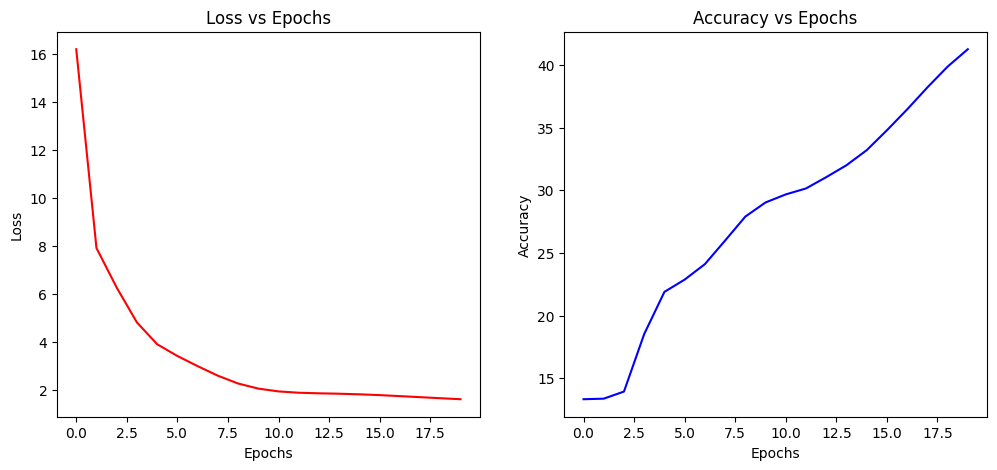

In [11]:
fig , ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(lossvalues.detach(),'r')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss vs Epochs')

ax[1].plot(training_acc, 'b')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy vs Epochs')
plt.show()

In [12]:
predictions_for_test_data = model.forward(xtest)

predlabels1 = torch.argmax(predictions_for_test_data,axis=1)
testacc = 100*torch.mean((predlabels1 == ytest).float())
print(testacc)

tensor(42.3857)


In [13]:
predictions_for_test_data.shape

torch.Size([14000, 10])

In [14]:
result = model.forward(xtest[18])
predlabels2 = torch.argmax(result)
predlabels2

tensor(5)

In [15]:
result.shape

torch.Size([10])

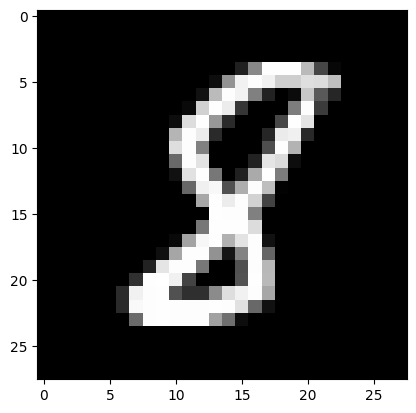

In [16]:
plt.imshow(xtest[18].reshape(28, 28), cmap='gray')

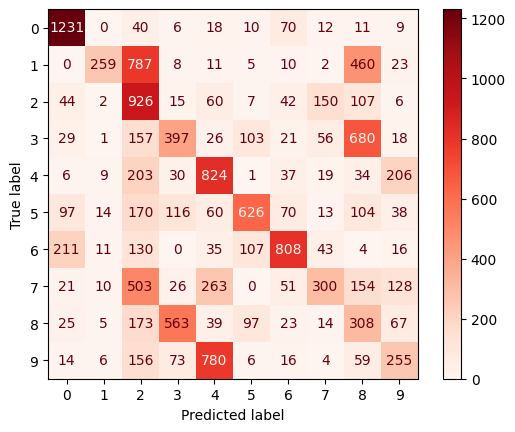

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(ytest, predlabels1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.show()